<a href="https://colab.research.google.com/github/vinayprabhu/DAMP/blob/main/notebooks/1_DATA_PROBE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Goal

The goal of this notebook is to scrape the peptide sequence datasets, concatenate them together and generate varification and probe datasets for the DAMP paper.

In [1]:
from google.colab import drive
import os
import pandas as pd
# 1. Mount Google Drive to the default mount point
drive.mount("/content/drive")
project_dir="/content/drive/MyDrive/AMR/DAMP"
os.chdir(project_dir)
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1_DATA_PROBE.ipynb
1_DATA_PROBE_refactored.ipynb
data_old
data_prefinal
raw_ven2.csv
temp_cell.csv
temp_csv.csv
uniprot_sprot_HomoSapiens_WithIsoF_2020_07_17_42361.fasta


In [2]:
# Make a data directory to store the assets

import os
from datetime import datetime

base_dir = "data"

if not os.path.exists(base_dir):
    os.makedirs(base_dir)
    target_dir = base_dir
else:
    date_str = datetime.now().strftime("%Y-%m-%d")
    target_dir = f"{base_dir}_{date_str}"
    os.makedirs(target_dir, exist_ok=True)

print(f"Target directory ready: {target_dir}")

Target directory ready: data


# 1. EXTINCTOME

"Deep-learning-enabled antibiotic discovery through molecular de-extinction"

 https://www.nature.com/articles/s41551-024-01201-x#MOESM1

FILTERING MODEL USED : APEX 1.0

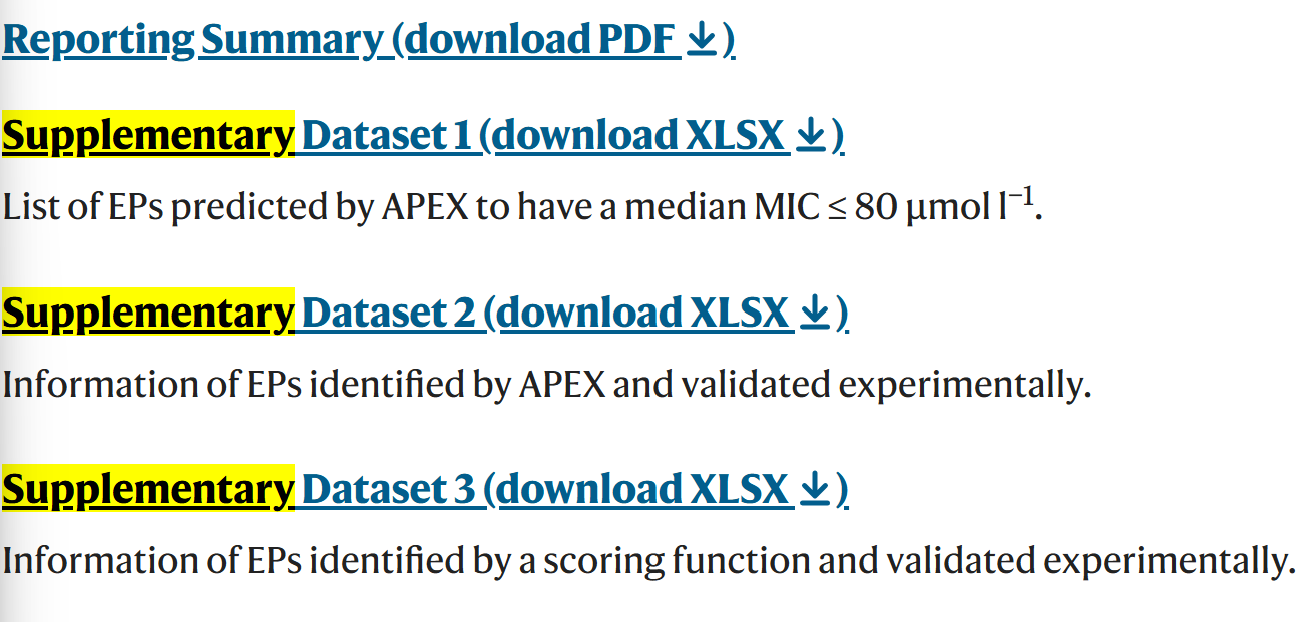

<img src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41551-024-01201-x/MediaObjects/41551_2024_1201_Fig1_HTML.png?as=webp" width="400" height="400">

In [3]:
# Loading .xlsx files directly into a pandas DataFrame via URL
url_ext1='https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41551-024-01201-x/MediaObjects/41551_2024_1201_MOESM3_ESM.xlsx'

url_ext2='https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41551-024-01201-x/MediaObjects/41551_2024_1201_MOESM4_ESM.xlsx'


url_ext3='https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41551-024-01201-x/MediaObjects/41551_2024_1201_MOESM5_ESM.xlsx'

In [4]:
df_ext1 = pd.read_excel(url_ext1,header=1)
df_ext2 = pd.read_excel(url_ext2,header=1)
df_ext3 = pd.read_excel(url_ext3,header=1)
print(df_ext1.shape)
print(df_ext2.shape)
print(df_ext3.shape)

(37176, 2)
(69, 22)
(49, 14)


In [5]:
df_ext1.head(2)

,Seq,Is AEP
0,SINSLIIKLIQADILKNKLS,No
1,MARNLVRYVQGLKKKKVI,No


In [6]:
df_ext2.head(2)

,Peptide name,Seq,Label,Peptide,A. baumannii ATCC19606,E. coli ATCC11775,E. coli AIG221,E. coli AIG222,K. pneumoniae ATCC13883,P. aeruginosa PAO1,...,S. aureus (ATCC BAA-1556) - MRSA,vancomycin-resistant E. faecalis ATCC700802,vancomycin-resistant E. faecium ATCC700221,AEP or MEP,Active or Inactive,Secreted or Non-secreted,Gram-positive,Gram-negative,Broad-spectrum,Source organisms
0,Equusin-1,IFLLLINLLGLL,DLF2178,ANT45580.1-IFL12,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,...,N.A.,N.A.,N.A.,MEP,Inactive,Non-secreted,Yes,No,Yes,Heteralocha acutirostris
1,Hesperelin-1,WFHFNSKILLLTGL,DLF2152,AWK29290.1-WFH14,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,...,N.A.,N.A.,8,AEP,Active,Non-secreted,No,No,Yes,Mylodon darwinii


In [7]:
df_ext3.head(2)

,Label,Peptide,Sequence,A. baumannii ATCC19606,E. coli ATCC11775,E. coli AIG221,E. coli AIG222,K. pneumoniae ATCC133883,P. aeruginosa PAO1,P. aeruginosa PA14,S. aureus ATCC12600,S. aureus (ATCC BAA-1556) - MRSA,E. faecalis ATCC700802 - VRE,E. faecium ATCC700221 - VRE
0,DLF1561,ACX48939.1_KYR08,KYRLKFRF,N.A.,64,32,64,N.A.,N.A.,64,N.A.,N.A.,N.A.,N.A.
1,DLF1562,AKN79944.1_KRI08,KRIRVAVV,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.


In [8]:
df_ext1.to_csv('./data/df_extinctome.tsv',sep='\t',index=False)
df_ext2.to_csv('./data/df_extinctome_2.tsv',sep='\t',index=False)
df_ext3.to_csv('./data/df_extinctome_3.tsv',sep='\t',index=False)

In [9]:
df_damp=pd.DataFrame(columns=['sequence','source','model','paper'])
df_damp['sequence']=df_ext1.Seq.values
df_damp['source']='Extinctomics'
df_damp['model']='APEX_1.0'
df_damp['paper']='https://doi.org/10.1038/s41551-024-01201-x'
df_damp.shape

(37176, 4)

In [10]:
df_damp.to_csv('./data/df_damp_ext.tsv',sep='\t',index=False)

# 2: VENOMICS

https://www.nature.com/articles/s41467-025-60051-6

"Computational exploration of global venoms for antimicrobial discovery with Venomics artificial intelligence"

Model used : APEX 1.0



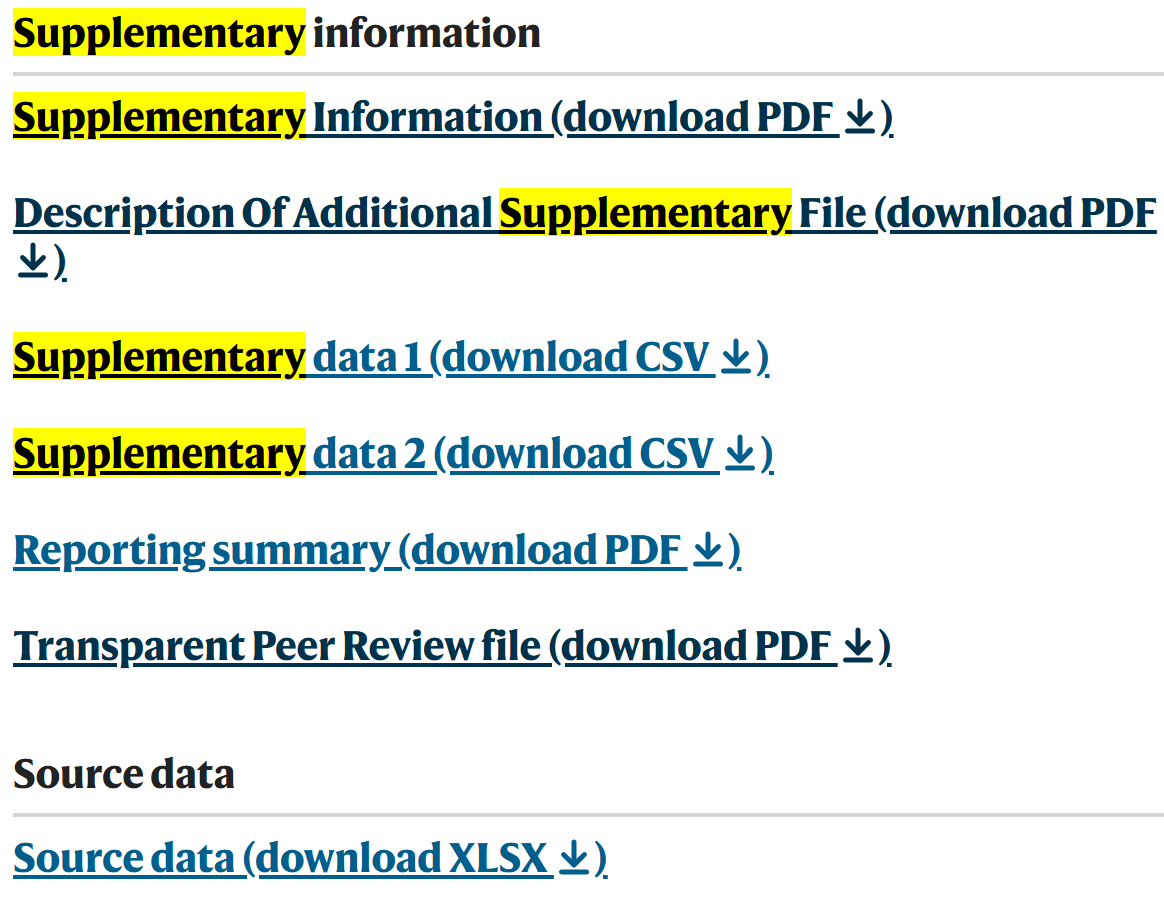

In [11]:
url_ven1='https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41467-025-60051-6/MediaObjects/41467_2025_60051_MOESM3_ESM.csv'
url_ven2='https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41467-025-60051-6/MediaObjects/41467_2025_60051_MOESM4_ESM.csv'
# url_ven3='https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41467-025-60051-6/MediaObjects/41467_2025_60051_MOESM7_ESM.xlsx' # 403 errors

url_ven3='https://github.com/vinayprabhu/DAMP/raw/refs/heads/main/data/41467_2025_60051_MOESM7_ESM.xlsx'

In [12]:
# Fix url_ven2 reading error by skipping malformed/unbalanced lines
df_ven1 = pd.read_csv(url_ven1)
# 1. Download raw CSV locally
!wget -q -O raw_ven2.csv "https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41467-025-60051-6/MediaObjects/41467_2025_60051_MOESM4_ESM.csv"

# 2. Install csvkit for file cleanup
!pip install -q csvkit

# 3. Clean unbalanced quotes and delimiters without dropping any lines
!csvclean raw_ven2.csv

# 4. Read the cleaned output file
df_ven2 = pd.read_csv("raw_ven2.csv")
df_ven3 = pd.read_excel(url_ven3, engine="openpyxl")



print(df_ven1.shape)
print(df_ven2.shape)
print(df_ven3.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.6/114.6 kB 5.1 MB/s eta 0:00:00
usage: csvclean [-h] [-d DELIMITER] [-t] [-q QUOTECHAR] [-u {0,1,2,3,4,5}]
                [-b] [-p ESCAPECHAR] [-z FIELD_SIZE_LIMIT] [-e ENCODING] [-S]
                [-H] [-K SKIP_LINES] [-v] [-l] [--add-bom] [--zero] [-V]
                [--length-mismatch] [--empty-columns] [-a] [--omit-error-rows]
                [--label LABEL] [--header-normalize-space] [--join-short-rows]
                [--separator SEPARATOR] [--fill-short-rows]
                [--fillvalue FILLVALUE]
                [FILE]
csvclean: error: No checks or fixes were enabled. See available options with: csvclean --help
(4618, 13)
(273, 16)
(890, 4)


In [13]:
df_ven2.head(2)

,Sequence,E. coli ATCC11775,P. aeruginosa PAO1,P. aeruginosa PA14,S. aureus ATCC12600,E. coli AIG221,E. coli AIG222,K. pneumoniae ATCC13883,A. baumannii ATCC19606,S. aureus (ATCC BAA-1556) - MRSA,vancomycin-resistant E. faecalis ATCC700802,vancomycin-resistant E. faecium ATCC700221,Row_Median,Identity_Score,Fasta ID,Species Info
0,KLLKIGLKSFARVLKKVL,7.631190,12.327312,17.705845,23.381573,10.479675,9.200577,22.421314,2.904406,24.321060,40.750954,5.032958,12.327312,54.5,sp|C0HLF5|TOP1B_OXYTA_18_KLL,Oxyopes takobius
1,WLGSALKIGAKLL,12.724848,44.433080,56.734222,11.008263,11.276782,8.039488,21.580276,6.238011,13.541629,40.066017,5.775434,12.724848,61.5,sp|P82423|WTX1A_NEOGO_13_WLG,Neoponera goeldii


In [14]:
df_ven3.head(4)

,Arachnoserver,conoserver,ISOB,UniprotKB
0,Agelena orientalis,Conus abbreviatus,Hydrophis stokesii,Acanthaster planci
1,Agelenopsis aperta,Conus achatinus,Bungarus caeruleus,Acanthophis antarcticus
2,Ancylometes,Conus adamsonii,Bungarus fasciatus,Acanthophis rugosus
3,Aphonopelma,Conus amadis,Daboia russelii,Acanthophis sp. Seram


In [15]:
df_ven1.to_csv('./data/df_verify_venomics.tsv',sep='\t',index=False)

In [16]:
df_damp_v=pd.DataFrame(columns=['sequence','source','model','paper'])
df_damp_v['sequence']=df_ven1.Sequence.values
df_damp_v['source']='Venomics'
df_damp_v['model']='APEX_1.0'
df_damp_v['paper']='https://doi.org/10.1038/s41467-025-60051-6'

In [17]:
df_damp_v.to_csv('./data/df_damp_v.tsv',sep='\t',index=False)

In [18]:
print(f'df_damp.shape before venomics merger: {df_damp.shape}')
df_damp=pd.concat([df_damp,df_damp_v])
print(f'df_damp.shape after venomics merger: {df_damp.shape}')
df_damp.shape

df_damp.shape before venomics merger: (37176, 4)
df_damp.shape after venomics merger: (41794, 4)


(41794, 4)

In [19]:
df_damp.paper.value_counts()

,count
paper,
https://doi.org/10.1038/s41551-024-01201-x,37176
https://doi.org/10.1038/s41467-025-60051-6,4618


In [20]:
df_damp.source.value_counts()

,count
source,
Extinctomics,37176
Venomics,4618


# 3. ARCHAEOME

"Deep learning reveals antibiotics in the archaeal proteome"

https://www.nature.com/articles/s41564-025-02061-0#MOESM3

APEX 1.1

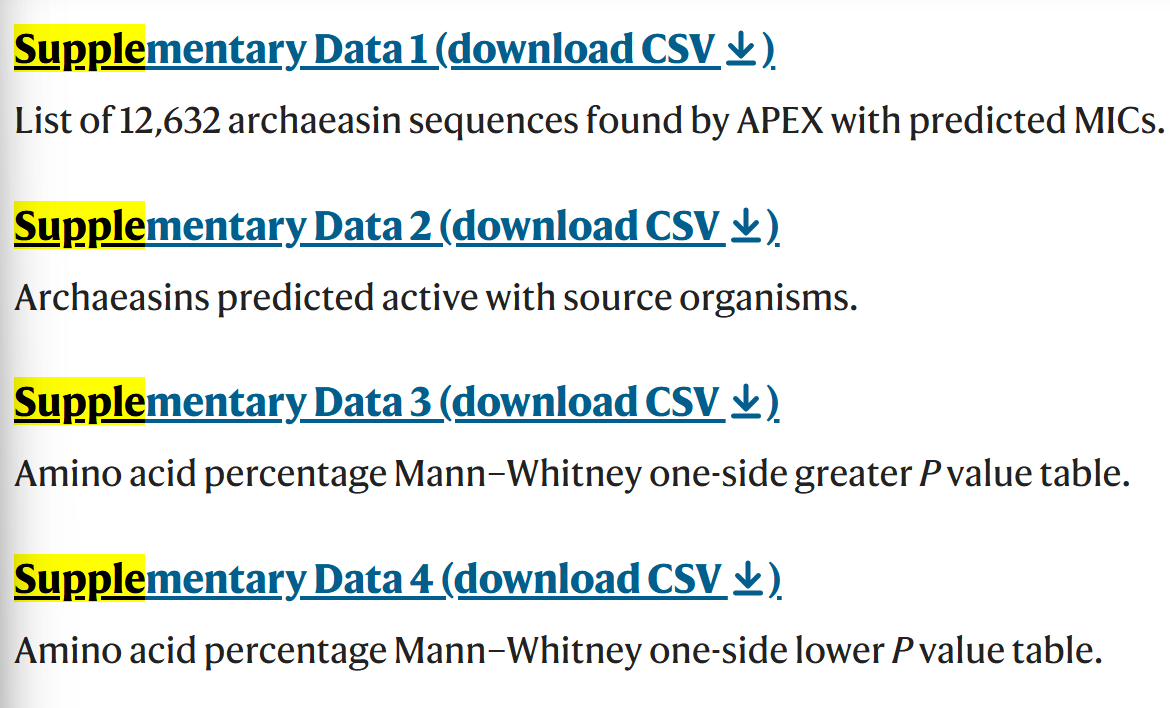

In [21]:
url_arch1='https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41564-025-02061-0/MediaObjects/41564_2025_2061_MOESM3_ESM.csv'
url_arch2='https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41564-025-02061-0/MediaObjects/41564_2025_2061_MOESM4_ESM.csv'
url_arch3='https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41564-025-02061-0/MediaObjects/41564_2025_2061_MOESM5_ESM.csv'
url_arch4='https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41564-025-02061-0/MediaObjects/41564_2025_2061_MOESM6_ESM.csv'

In [22]:
import csv
# Specialized CSV parsing function after encountering a few errors
def read_csv(url):
  # Download the raw file
  !wget -q -O temp_csv.csv $url

  # Robustly parse CSV while retaining multi-line quoted fields
  rows = []
  with open("temp_csv.csv", mode="r", encoding="utf-8-sig", errors="replace") as f:
      reader = csv.reader(f)
      header = next(reader)
      for r in reader:
          rows.append(r)

  # Convert directly into pandas DataFrame
  df_out = pd.DataFrame(rows, columns=header)
  return df_out

In [23]:
df_arch1=read_csv(url_arch1)
df_arch2=read_csv(url_arch2)
df_arch3=read_csv(url_arch3)
df_arch4=read_csv(url_arch4)

df_arch1.shape,df_arch2.shape,df_arch3.shape,df_arch4.shape

((12623, 13), (265, 16), (20, 7), (20, 7))

In [24]:
df_arch1.head()

,,A. baumannii ATCC 19606,E. coli ATCC 11775,E. coli AIG221,E. coli AIG222,K. pneumoniae ATCC 13883,P. aeruginosa PA01,P. aeruginosa PA14,S. aureus ATCC 12600,S. aureus (ATCC BAA-1556) - MRSA,vancomycin-resistant E. faecalis ATCC 700802,vancomycin-resistant E. faecium ATCC 700221,MeanMIC
0,WRRIRWALKLVRLW,5.299768,6.92004,8.106747,7.3595133,80.08063,21.469782,30.570768,55.69088,28.437466,81.06784,2.1262112,29.739058681818186
1,WRRIRWALKLVKLW,4.4421377,8.4753275,7.4186516,5.7390924,69.08144,42.91245,43.579414,39.110703,27.407877,107.06217,4.368083,32.69066783636364
2,KWILSRLHRIIKF,4.036451,5.4259176,4.326702,5.0439024,59.20341,24.534618,51.75372,36.336113,44.171566,133.12457,3.2396631,33.74514846363636
3,IGLLSRGLIKRINL,4.9090166,14.784844,12.069079,9.487346,46.165424,37.726246,65.9413,14.880726,13.470696,151.18187,5.185998,34.16386778181818
4,LGRLLIRRSLRIL,5.1633205,11.0548,5.1909013,7.449967,38.15998,48.80184,45.47916,28.007801,23.748972,187.02592,4.6906,36.79756925454546


In [25]:
df_arch1.to_csv('./data/df_verify_archaeomics.tsv',sep='\t',index=False)

In [26]:
df_damp_arch=pd.DataFrame(columns=df_damp.columns)
df_damp_arch['sequence']=df_arch1.iloc[:,0].values
df_damp_arch['model']='APEX_1.1'
df_damp_arch['source']='Archaeomics'
df_damp_arch['paper']='https://doi.org/10.1038/s41564-025-02061-0'

df_damp_arch.head(4)

,sequence,source,model,paper
0,WRRIRWALKLVRLW,Archaeomics,APEX_1.1,https://doi.org/10.1038/s41564-025-02061-0
1,WRRIRWALKLVKLW,Archaeomics,APEX_1.1,https://doi.org/10.1038/s41564-025-02061-0
2,KWILSRLHRIIKF,Archaeomics,APEX_1.1,https://doi.org/10.1038/s41564-025-02061-0
3,IGLLSRGLIKRINL,Archaeomics,APEX_1.1,https://doi.org/10.1038/s41564-025-02061-0


In [27]:
df_damp_arch.to_csv('./data/df_damp_arch.tsv',sep='\t',index=False)

In [28]:
print(f'Pre-Archaeomics merger shape: {df_damp.shape}')
df_damp=pd.concat([df_damp,df_damp_arch])
print(f'Post-Archaeomics merger shape: {df_damp.shape}')

Pre-Archaeomics merger shape: (41794, 4)
Post-Archaeomics merger shape: (54417, 4)


In [29]:
df_damp.paper.value_counts()

,count
paper,
https://doi.org/10.1038/s41551-024-01201-x,37176
https://doi.org/10.1038/s41564-025-02061-0,12623
https://doi.org/10.1038/s41467-025-60051-6,4618


In [30]:
df_damp.source.value_counts()

,count
source,
Extinctomics,37176
Archaeomics,12623
Venomics,4618


# 4: AMP-Diffusion
https://www.cell.com/cell-biomaterials/fulltext/S3050-5623(25)00174-6

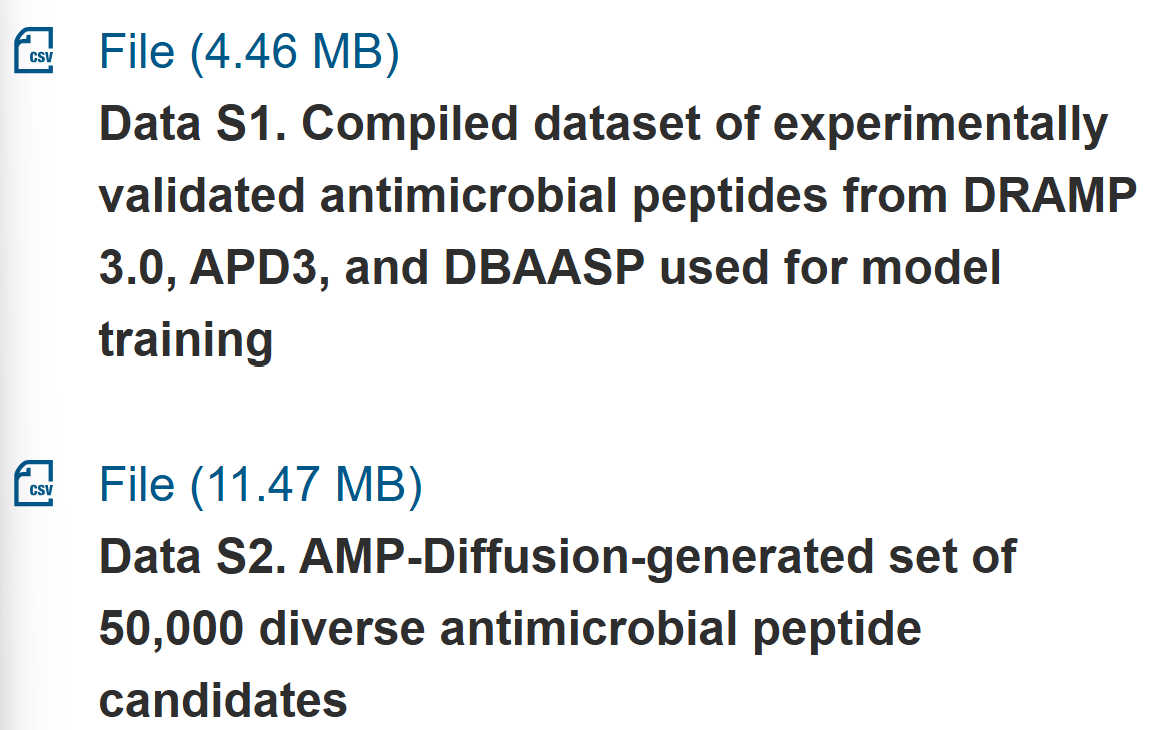

In [31]:
url_train_ampdiff_dad='https://raw.githubusercontent.com/vinayprabhu/DAMP/refs/heads/main/data/ampdiff_mmc2.csv'
url_ad='https://raw.githubusercontent.com/vinayprabhu/DAMP/refs/heads/main/data/ampdiff_mmc3.csv'

In [32]:
df_dad= pd.read_csv(url_train_ampdiff_dad)
df_dad.shape

(19670, 20)

In [33]:
df_dad.head(4)

,sequence,A. baumannii ATCC 19606,E. coli ATCC 11775,E. coli AIG221,E. coli AIG222,K. pneumoniae ATCC 13883,P. aeruginosa PA01,P. aeruginosa PA14,S. aureus ATCC 12600,S. aureus (ATCC BAA-1556) - MRSA,vancomycin-resistant E. faecalis ATCC 700802,vancomycin-resistant E. faecium ATCC 700221,average_MIC,ppl,molar_weight,charge,isoelectric_point,aromaticity,hydrophobicity,hydrophobic_moment
0,FFKKWPWWPWRRK,311.83276,350.54626,223.16974,115.971344,512.69460,436.09180,459.94125,498.13135,465.31375,524.23460,79.425095,361.577504,26.303656,1948.32,5.995,12.179688,0.461538,-0.278462,0.234824
1,RSVCRQIKICRRRGGCYYLCTNRPY,227.46667,310.24854,178.52353,276.092960,397.63280,333.55890,341.03897,425.70325,525.86640,470.94350,139.206100,329.661966,21.553949,3065.63,7.723,10.262939,0.120000,-0.413600,0.428818
2,PKTLRKFFARIRGGRAAVLNALGKEEQIGRASNSGRKCARKKK,94.80340,282.74527,114.55809,197.335570,347.64325,239.35048,236.06496,319.96450,394.00723,471.87756,96.055530,254.036894,17.972723,4769.60,12.930,12.046387,0.046512,-0.376047,0.198247
3,SNTALRRYNQWATGHFM,475.75348,503.65576,491.27188,507.683650,510.73117,511.33206,510.19193,507.62564,510.95834,512.98440,464.576420,500.614976,22.856602,2053.27,3.094,10.980469,0.176471,-0.138824,0.315313


In [34]:
df_damp_dad=pd.DataFrame(columns=df_damp.columns)
df_damp_dad['sequence']=df_dad.sequence.values
df_damp_dad['model']='CANONICAL_DATASETS'
df_damp_dad['source']='DRAMP_APD_DBAASP'
df_damp_dad['paper']='https://doi.org/10.1016/j.celbio.2025.100183'
print(f'Pre-merger shape: {df_damp.shape}')
df_damp=pd.concat([df_damp,df_damp_dad])
print(f'Post-merger shape: {df_damp.shape}')

Pre-merger shape: (54417, 4)
Post-merger shape: (74087, 4)


In [35]:
df_damp_dad.to_csv('./data/df_damp_dad.tsv',sep='\t',index=False)

In [36]:
df_ampdiff=pd.read_csv(url_ad)
df_ampdiff.head(4)

,sequence,A. baumannii ATCC 19606,E. coli ATCC 11775,E. coli AIG221,E. coli AIG222,K. pneumoniae ATCC 13883,P. aeruginosa PA01,P. aeruginosa PA14,S. aureus ATCC 12600,S. aureus (ATCC BAA-1556) - MRSA,vancomycin-resistant E. faecalis ATCC 700802,vancomycin-resistant E. faecium ATCC 700221,average_MIC,ppl,molar_weight,charge,isoelectric_point,aromaticity,hydrophobicity,hydrophobic_moment
0,MKWLKIALRGLRMKL,4.343103,24.810188,6.818177,6.583273,76.958400,24.484667,25.16784,92.565960,94.732320,318.19794,4.073182,61.703186,19.920242,1857.43,5.995,12.179688,0.066667,-0.034000,0.506760
1,MWRLKKWLRLLRWRF,5.700647,4.539224,6.441539,6.537109,126.110016,12.973155,21.99933,32.378075,25.049667,199.16006,2.247043,40.285079,20.243412,2188.73,6.995,12.591309,0.266667,-0.288667,0.390793
2,MLIRWLLAAIKYWRK,15.571178,39.764300,33.595646,26.613089,190.159600,66.262450,87.93409,35.650417,29.998755,159.58829,5.096312,62.748557,21.513887,1961.47,4.995,11.427734,0.200000,0.124000,0.593205
3,MFARPIARKILRALFK,4.273494,42.936966,10.918715,17.740175,48.326250,22.084760,163.36372,29.803730,54.482857,105.08603,2.310006,45.575155,18.657009,1931.44,5.995,12.424316,0.125000,-0.030000,0.619932


In [37]:
df_ampdiff.to_csv('./data/df_verify_AMPDiff.tsv',sep='\t',index=False)

In [38]:
df_damp_ampdiff=pd.DataFrame(columns=df_damp.columns)
df_damp_ampdiff['sequence']=df_ampdiff.sequence.values
df_damp_ampdiff['model']='APEX_1.1'
df_damp_ampdiff['source']='AMPDIFF_synth50k'
df_damp_ampdiff['paper']='https://doi.org/10.1016/j.celbio.2025.100183'
df_damp_ampdiff.shape

(50000, 4)

In [39]:
df_damp_ampdiff.to_csv('./data/df_damp_ampdiff_50k.tsv',sep='\t',index=False)

In [40]:
print(f'Pre-merger shape: {df_damp.shape}')
df_damp=pd.concat([df_damp,df_damp_ampdiff])
print(f'Post-merger shape: {df_damp.shape}')

Pre-merger shape: (74087, 4)
Post-merger shape: (124087, 4)


In [41]:
df_damp.source.value_counts()

,count
source,
AMPDIFF_synth50k,50000
Extinctomics,37176
DRAMP_APD_DBAASP,19670
Archaeomics,12623
Venomics,4618


# 5. HUMAN PROTEOME

https://www.nature.com/articles/s41551-022-00967-2


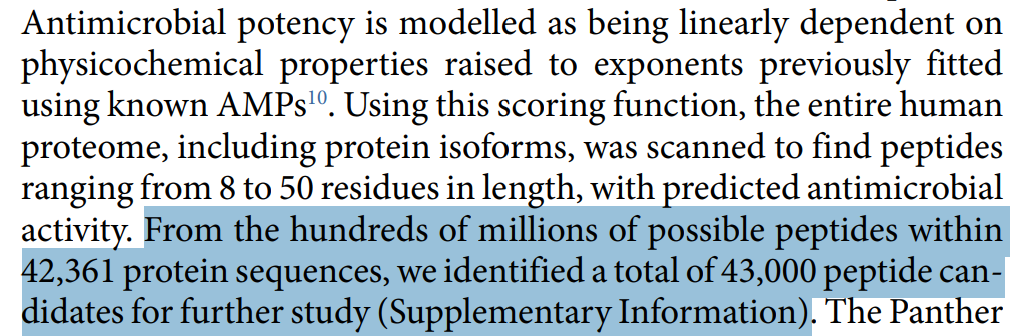



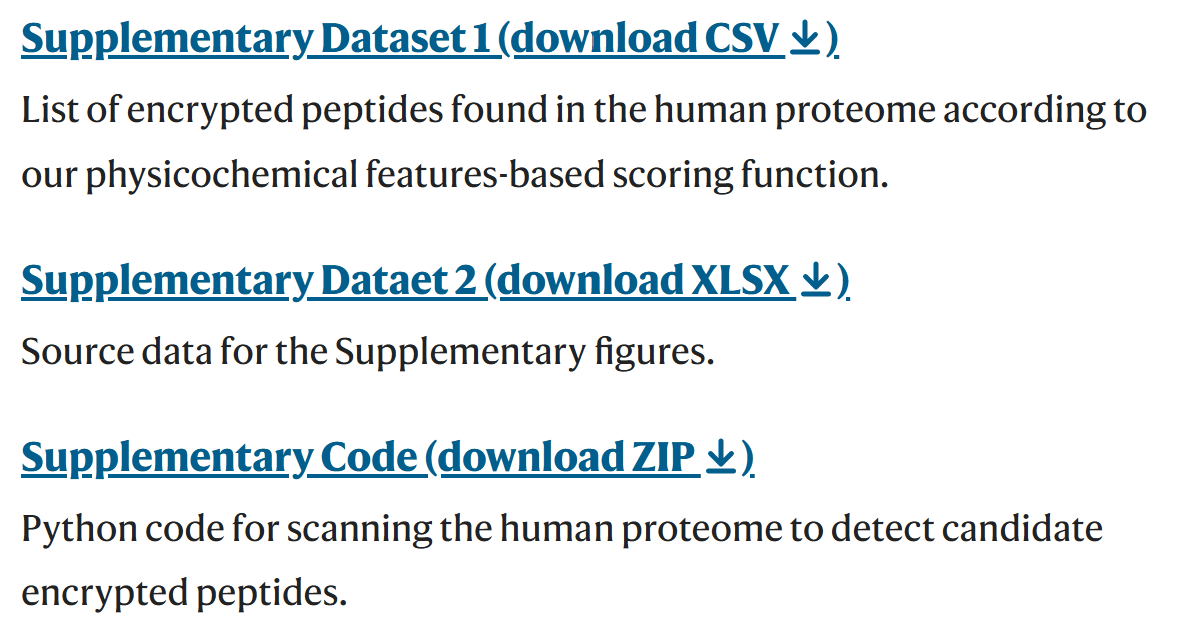

The supplementary code had the fasta file that I have manually downloaded here.



In [42]:
!pip install -q biopython
import pandas as pd
from Bio import SeqIO

def fasta_to_df(file_path):
    records = []
    for record in SeqIO.parse(file_path, "fasta"):
        records.append({
            "ID": record.id,
            "Description": record.description,
            "Sequence": str(record.seq)
        })
    return pd.DataFrame(records)

# Use the FASTA filename specified in your active cell
file_human_proteome = 'uniprot_sprot_HomoSapiens_WithIsoF_2020_07_17_42361.fasta'
df_fasta = fasta_to_df(file_human_proteome)

print(df_fasta.shape)
df_fasta.head(3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 12.6 MB/s eta 0:00:00
(42361, 3)


,ID,Description,Sequence
0,sp|P31946|1433B_HUMAN,sp|P31946|1433B_HUMAN 14-3-3 protein beta/alph...,MTMDKSELVQKAKLAEQAERYDDMAAAMKAVTEQGHELSNEERNLL...
1,sp|P62258|1433E_HUMAN,sp|P62258|1433E_HUMAN 14-3-3 protein epsilon O...,MDDREDLVYQAKLAEQAERYDEMVESMKKVAGMDVELTVEERNLLS...
2,sp|Q04917|1433F_HUMAN,sp|Q04917|1433F_HUMAN 14-3-3 protein eta OS=Ho...,MGDREQLLQRARLAEQAERYDDMASAMKAVTELNEPLSNEDRNLLS...


In [43]:
url_hp_1='https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41551-021-00801-1/MediaObjects/41551_2021_801_MOESM3_ESM.csv'
df_hp=pd.read_csv(url_hp_1)
print(df_hp.shape)

(43000, 7)


In [44]:
df_hp.head()

,RecID,start,len,ptnLen,relativeScore,absoluteScore,sequence
0,sp|O15020|SPTN2_HUMAN,640,8,2390,0.968220,7.745757,RRLWRFLW
1,sp|Q9C0H6|KLHL4_HUMAN,14,8,718,0.968220,7.745757,LRLRWRWF
2,sp|Q9UKJ0|PILRB_HUMAN,209,8,227,0.968220,7.745757,LLLWWRRR
3,sp|O00763|ACACB_HUMAN,2327,8,2458,0.957647,7.661177,WRLRRLLL
4,sp|Q6UY18|LIGO4_HUMAN,366,8,593,0.957647,7.661177,LWLLRLRR


As per my intuition, ``` df_hp ```'s sequence column was derived from the human proteome fasta file where you use the ```RecID``` entry to find the exact ```ID``` match and then cleave the subosequence of length ```len``` beginning from location ```start```.

Let us test this out!





In [45]:
import random
for trials in range(4):
  IND_TEST = random.randint(0, df_hp.shape[0])
  print(f'IND_TEST = {IND_TEST}')
  raw_seq=df_fasta.loc[df_fasta.ID == df_hp.loc[IND_TEST,'RecID'],'Sequence'].values[0]
  ind_beg=df_hp.loc[IND_TEST,'start']
  ind_end=ind_beg+df_hp.loc[IND_TEST,'len']
  if(raw_seq[ind_beg:ind_end]==df_hp.loc[IND_TEST,'sequence']):
    print(f'They match! {raw_seq[ind_beg:ind_end]}')
  else:
    print(f'{raw_seq[ind_beg:ind_end],df_hp.loc[IND_TEST,'sequence']}')


IND_TEST = 25618
They match! VVLSSKVCRGYLVKMGGKIKSWKKRWFVFDRLK
IND_TEST = 39503
They match! RRAKRKVTRMILIVAALFCLCWMPHHALILCVWFGQFPLTRATYALR
IND_TEST = 19911
They match! KTLRLRKNTVKFSLYRHFKNTLIFAVL
IND_TEST = 38773
They match! YLKSNWLGLRFLRALRLLELPQILQILRAIKTSNSVKFSKLLSIIL


Cool, let us proceed to add this to the overall ```df_damp``` dataframe.

In [46]:
df_damp_hp=pd.DataFrame(columns=df_damp.columns)
df_damp_hp['sequence']=df_hp.sequence.values
df_damp_hp['model']='AMP_potency_score_pane_et_al'
df_damp_hp['source']='Human_Proteomics'
df_damp_hp['paper']='https://doi.org/10.1038/s41551-021-00801-1'
df_damp_hp.shape

(43000, 4)

In [47]:
df_damp_hp.to_csv('./data/df_damp_hp.tsv',sep='\t',index=False)
print(f'Pre-merger shape: {df_damp.shape}')
df_damp=pd.concat([df_damp,df_damp_hp])
print(f'Post-merger shape: {df_damp.shape}')

Pre-merger shape: (124087, 4)
Post-merger shape: (167087, 4)


# 6 : NEURIPS AMP CHALLENGE DATASET



In [48]:
url_fasta= 'https://raw.githubusercontent.com/szczurek-lab/amp-challenge-2027/refs/heads/main/data/antibacterial.fasta'

import requests
import io
import pandas as pd
from Bio import SeqIO

# Fetch the fasta file from the URL
response = requests.get(url_fasta)
response.raise_for_status()

# Parse the text stream and extract records
records = []
for record in SeqIO.parse(io.StringIO(response.text), "fasta"):
    records.append({
        "ID": record.id,
        "Description": record.description,
        "Sequence": str(record.seq)
    })

# Convert directly into a pandas DataFrame
df_neurips = pd.DataFrame(records)
print(df_neurips.shape)
df_neurips.head(2)

(39448, 3)


,ID,Description,Sequence
0,MLAMP0003076,MLAMP0003076 len=15 charge=4.73 disulfide=0 db...,VNWKKILGKIIKVVK
1,MLAMP0000439,MLAMP0000439 len=16 charge=0.76 disulfide=0 db...,GLFDVIKKVASVIGGL


In [49]:
df_damp_neurips=pd.DataFrame(columns=df_damp.columns)
df_damp_neurips['sequence']=df_neurips.Sequence.values
df_damp_neurips['model']='UNCLEAR'
df_damp_neurips['source']='NEURIPS_AMP_CHALLENGE'
df_damp_neurips['paper']='https://github.com/szczurek-lab/amp-challenge-2027/blob/main/AMPChallenge_NeurIPSCompetition.pdf'
df_damp_neurips.shape

(39448, 4)

In [50]:
df_damp_neurips.to_csv('./data/df_damp_neurips.tsv',sep='\t',index=False)
print(f'Pre-merger shape: {df_damp.shape}')
df_damp=pd.concat([df_damp,df_damp_neurips])
print(f'Post-merger shape: {df_damp.shape}')

Pre-merger shape: (167087, 4)
Post-merger shape: (206535, 4)


In [51]:
print(df_damp.shape)
df_damp.to_csv('./data/df_damp_09_16_26.tsv',sep='\t',index=False)
df_damp.source.value_counts()

(206535, 4)


,count
source,
AMPDIFF_synth50k,50000
Human_Proteomics,43000
NEURIPS_AMP_CHALLENGE,39448
Extinctomics,37176
DRAMP_APD_DBAASP,19670
Archaeomics,12623
Venomics,4618


In [53]:
df_damp.model.value_counts()

,count
model,
APEX_1.1,62623
AMP_potency_score_pane_et_al,43000
APEX_1.0,41794
UNCLEAR,39448
CANONICAL_DATASETS,19670


In [58]:
(df_damp.sequence.value_counts()>1).sum(),(df_damp.sequence.value_counts()>2).sum(),df_damp.shape[0]-df_damp.sequence.nunique()

(np.int64(15504), np.int64(58), 15562)

In [70]:
df_damp = df_damp.drop_duplicates(subset=['sequence'], keep='first')
# Reset the index and drop the old index column
df_damp = df_damp.reset_index(drop=True)
df_damp.source.value_counts()

,count
source,
AMPDIFF_synth50k,49986
Human_Proteomics,42995
Extinctomics,37176
NEURIPS_AMP_CHALLENGE,23953
DRAMP_APD_DBAASP,19622
Archaeomics,12623
Venomics,4618


In [71]:
df_damp.to_csv('./data/df_damp_190973x4.tsv',sep='\t', index=False)

In [72]:
df_d2=pd.read_csv('./data_damp/df_damp_190973x4.tsv',sep='\t')
df_d2.shape

(190973, 4)

In [73]:
df_d2.equals(df_damp)

True

In [74]:
df_d1=pd.read_csv('./data/df_damp_09_16_26.tsv',sep='\t')
df_d2=pd.read_csv('./data/df_damp_190973x4.tsv',sep='\t')
df_d1.shape,df_d2.shape

((206535, 4), (190973, 4))

In [77]:
df_d1

,sequence,source,model,paper
0,SINSLIIKLIQADILKNKLS,Extinctomics,APEX_1.0,https://doi.org/10.1038/s41551-024-01201-x
1,MARNLVRYVQGLKKKKVI,Extinctomics,APEX_1.0,https://doi.org/10.1038/s41551-024-01201-x
2,KWTKIYLPLLL,Extinctomics,APEX_1.0,https://doi.org/10.1038/s41551-024-01201-x
3,NLVRYVQGLKKKKVIVIPVGIG,Extinctomics,APEX_1.0,https://doi.org/10.1038/s41551-024-01201-x
4,EIKIYKKL,Extinctomics,APEX_1.0,https://doi.org/10.1038/s41551-024-01201-x
...,...,...,...,...
206530,MTKKNLKPQQAAPVQREINTTSSESGTSTGLTPHQAYLGIPLPFAG...,NEURIPS_AMP_CHALLENGE,UNCLEAR,https://github.com/szczurek-lab/amp-challenge-...
206531,ARLHRPSEFARLGLVIAKRFAARAVTRNTLKRVIRELDYVVLKRSA...,NEURIPS_AMP_CHALLENGE,UNCLEAR,https://github.com/szczurek-lab/amp-challenge-...
206532,DKFSTNEEFSKIAVVASKKVGKAVVRNRSKRILRALQKYIFLEKNL...,NEURIPS_AMP_CHALLENGE,UNCLEAR,https://github.com/szczurek-lab/amp-challenge-...
206533,DSLKNKSEFDKLGLSVSKKVGNAVKRNLIKRRLRSCQALVFLEKHF...,NEURIPS_AMP_CHALLENGE,UNCLEAR,https://github.com/szczurek-lab/amp-challenge-...


In [80]:
# 1. Identify sequences appearing more than once
counts = df_d1['sequence'].value_counts()
dupes = counts[counts > 1].index

# 2. Filter the original dataframe (using df_d1 based on your active cell)
df_filtered = df_d1[df_d1['sequence'].isin(dupes)]

# 3. Group by sequence and aggregate the source column with unique values
df_repeating = df_filtered.groupby('sequence', as_index=False).agg(
    source=('source', lambda x: ' | '.join(x.dropna().unique().astype(str)))
)

df_repeating.head()

,sequence,source
0,AAA,DRAMP_APD_DBAASP | AMPDIFF_synth50k
1,AAAAAAAAAAGIGKFLHSAKKFGKAFVGEIMNS,DRAMP_APD_DBAASP | NEURIPS_AMP_CHALLENGE
2,AAAALFNRSFTQALGK,DRAMP_APD_DBAASP | NEURIPS_AMP_CHALLENGE
3,AAAALSRAALRAAVA,DRAMP_APD_DBAASP | NEURIPS_AMP_CHALLENGE
4,AAAALSRWWLRWWVA,DRAMP_APD_DBAASP | NEURIPS_AMP_CHALLENGE


In [81]:
df_repeating.source.value_counts()

,count
source,
DRAMP_APD_DBAASP | NEURIPS_AMP_CHALLENGE,15408
Venomics | DRAMP_APD_DBAASP | NEURIPS_AMP_CHALLENGE,46
Venomics | NEURIPS_AMP_CHALLENGE,16
AMPDIFF_synth50k | NEURIPS_AMP_CHALLENGE,9
DRAMP_APD_DBAASP | AMPDIFF_synth50k,8
DRAMP_APD_DBAASP | AMPDIFF_synth50k | NEURIPS_AMP_CHALLENGE,6
DRAMP_APD_DBAASP | Human_Proteomics | NEURIPS_AMP_CHALLENGE,4
Human_Proteomics | NEURIPS_AMP_CHALLENGE,4
Archaeomics | DRAMP_APD_DBAASP | NEURIPS_AMP_CHALLENGE,2


In [82]:
df_damp.source.unique()

array(['Extinctomics', 'Venomics', 'Archaeomics', 'DRAMP_APD_DBAASP',
       'AMPDIFF_synth50k', 'Human_Proteomics', 'NEURIPS_AMP_CHALLENGE'],
      dtype=object)

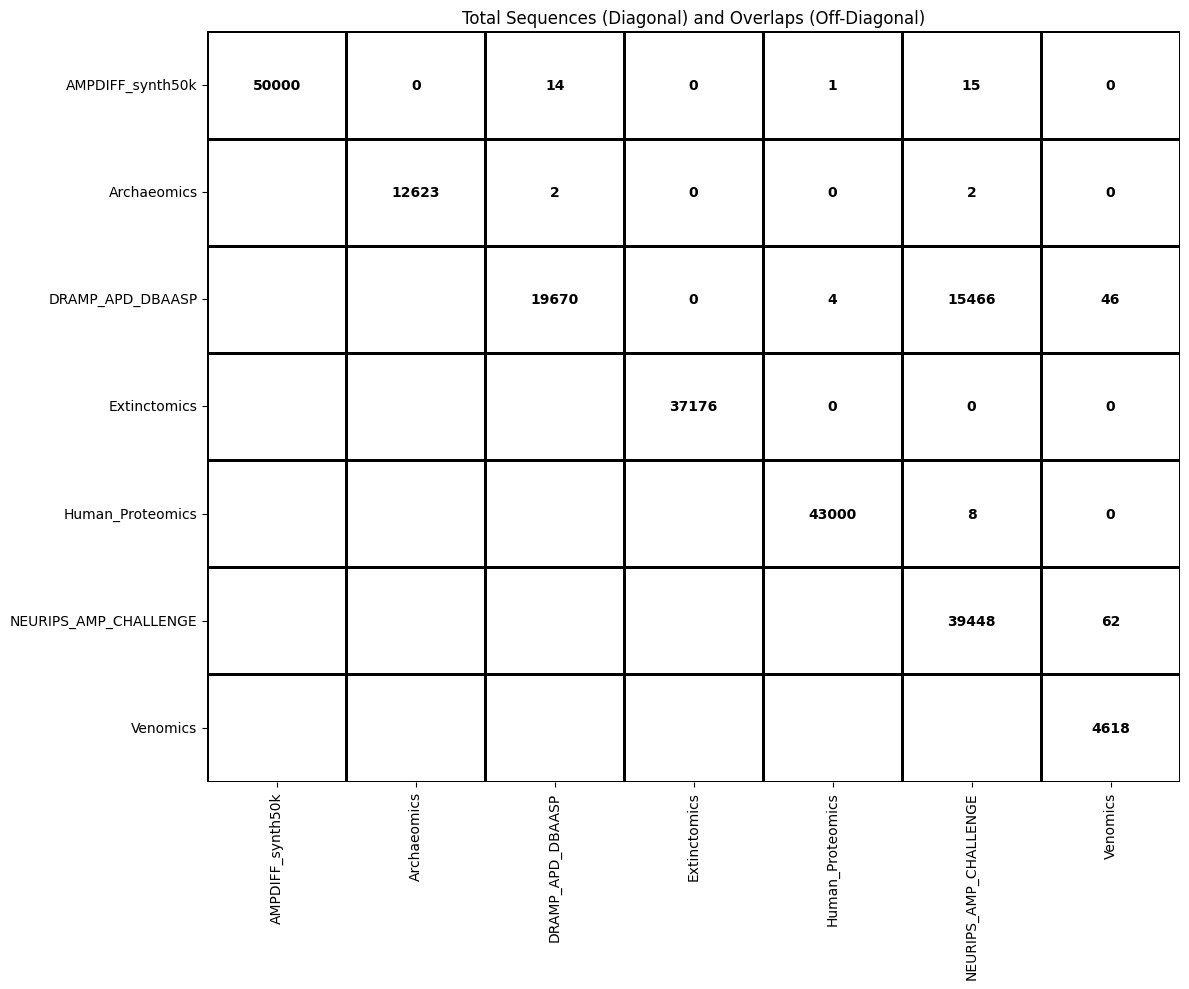

In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Map each source to its set of unique sequences using your base dataframe
source_sets = df_d1.groupby('source')['sequence'].apply(set).to_dict()
sources = sorted(source_sets.keys())

# Initialize the square overlap matrix
df_heatmap = pd.DataFrame(index=sources, columns=sources, dtype=float)

# Populate the matrix with set intersections and total lengths
for i, src1 in enumerate(sources):
    for j, src2 in enumerate(sources):
        if i == j:
            df_heatmap.loc[src1, src2] = len(source_sets[src1])
        else:
            overlap = len(source_sets[src1].intersection(source_sets[src2]))
            df_heatmap.loc[src1, src2] = overlap

# Generate a mask for the lower triangle
mask = np.tril(np.ones_like(df_heatmap, dtype=bool), k=-1)

# Create a plain white colormap
white_cmap = ListedColormap(['white'])

# Render the heatmap with a white background, black text, and cell borders
plt.figure(figsize=(12, 10))
sns.heatmap(
    df_heatmap,
    mask=mask,
    annot=True,
    fmt="g",
    cmap=white_cmap,
    cbar=False,
    linewidths=1,
    linecolor='black',
    annot_kws={"size": 10, "weight": "bold", "color": "black"}
)
plt.title("Total Sequences (Diagonal) and Overlaps (Off-Diagonal)")
plt.tight_layout()
plt.show()

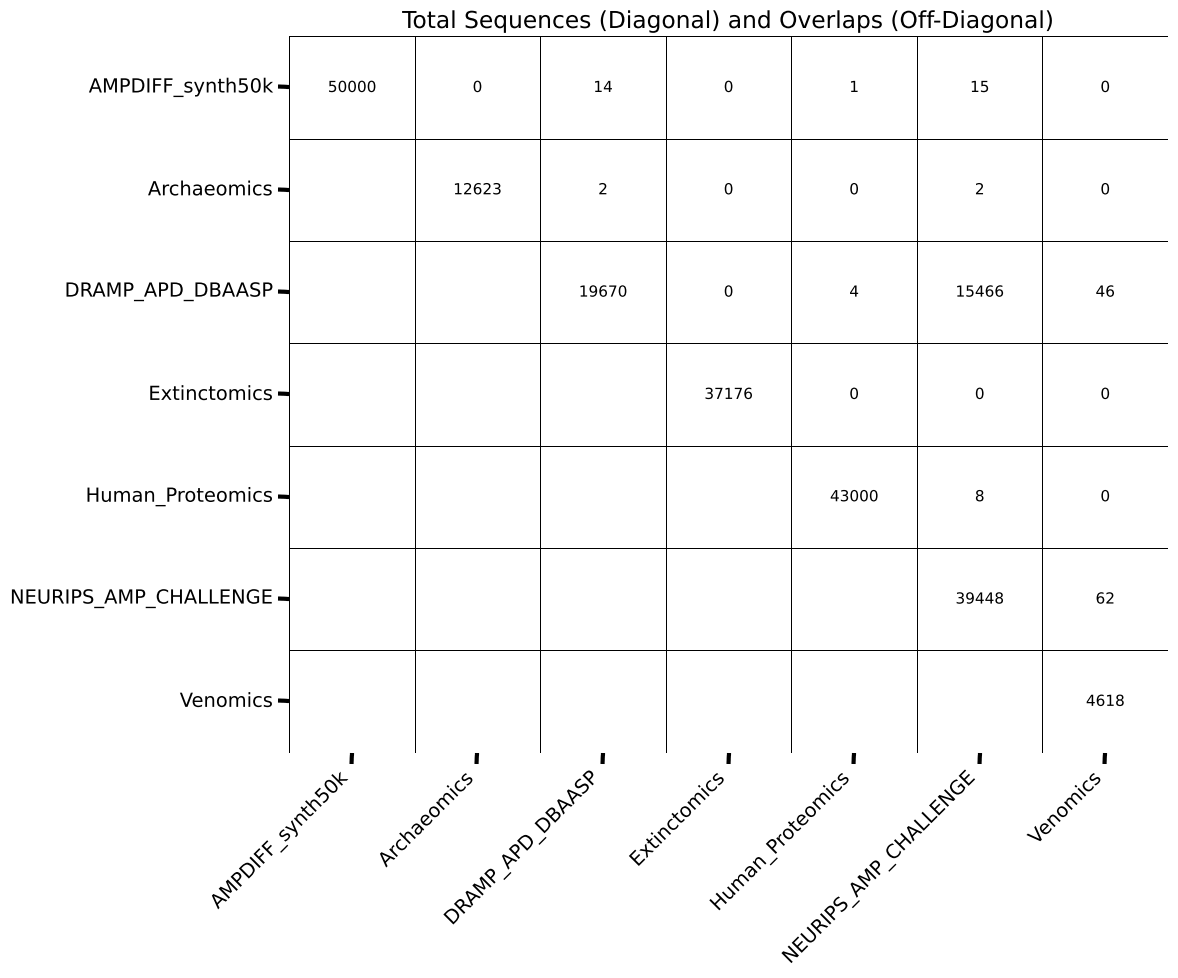

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
from matplotlib.colors import ListedColormap

# Suppress missing font warnings from matplotlib
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")

# Map each source to its set of unique sequences
source_sets = df_d1.groupby('source')['sequence'].apply(set).to_dict()
sources = sorted(source_sets.keys())

# Initialize the square overlap matrix
df_heatmap = pd.DataFrame(index=sources, columns=sources, dtype=float)

# Populate the matrix with set intersections and total lengths
for i, src1 in enumerate(sources):
    for j, src2 in enumerate(sources):
        if i == j:
            df_heatmap.loc[src1, src2] = len(source_sets[src1])
        else:
            overlap = len(source_sets[src1].intersection(source_sets[src2]))
            df_heatmap.loc[src1, src2] = overlap

# Generate a mask for the lower triangle
mask = np.tril(np.ones_like(df_heatmap, dtype=bool), k=-1)
white_cmap = ListedColormap(['white'])

# Apply XKCD styling context manager
with plt.xkcd():
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        df_heatmap,
        mask=mask,
        annot=True,
        fmt="g",
        cmap=white_cmap,
        cbar=False,
        linewidths=0.5,
        linecolor='black',
        annot_kws={"size": 11, "color": "black"}
    )
    plt.title("Total Sequences (Diagonal) and Overlaps (Off-Diagonal)")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()